<a href="https://colab.research.google.com/github/barco8336-star/Inteligencia-de-Negocios/blob/main/Caso_Regresion_Logistica.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#PARTE A

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from google.colab import drive
import pandas as pd


drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#Carga de los archivos
ruta_carpeta = '/content/drive/MyDrive/Prueba Técnica/db/Parte_A'

archivos = [f for f in os.listdir(ruta_carpeta) if f.startswith('empresa')]


lista_df = []
for archivo in archivos:
    ruta_completa = os.path.join(ruta_carpeta, archivo)
    df_temp = pd.read_csv(ruta_completa)


    df_temp['origen_archivo'] = archivo

    lista_df.append(df_temp)

df_final = pd.concat(lista_df, ignore_index=True)

print(f"¡Hecho! Se concatenaron {len(archivos)} archivos.")
df_final.head()

¡Hecho! Se concatenaron 25 archivos.


,Unnamed: 0,id_agencia,id_cliente,departamento,municipio,fecha_nacimiento,fecha_ingreso_cac,codigo_profesion,codigo_ocupacion,genero,estado_civil,actualizacion_ive,negocio_propio,origen_archivo,fecha_nacimiento.1
0,1,1,1.0,NaN,NaN,1970-01-01,2009-01-08,25.0,169.0,0,SOLTERO,2009-01-08,N,empresa08.csv,NaN
1,2,1,97.0,NaN,NaN,1970-01-01,2009-01-08,25.0,169.0,M,SOLTERO,2009-01-08,N,empresa08.csv,NaN
2,3,1,98.0,NaN,NaN,1990-01-01,2009-02-19,25.0,169.0,M,SOLTERO,2009-02-19,N,empresa08.csv,NaN
3,4,1,99.0,NaN,NaN,1970-01-01,2009-01-08,25.0,169.0,M,SOLTERO,2009-01-08,N,empresa08.csv,NaN
4,5,1,101.0,ALTA VERAPAZ,COBAN,1969-03-20,1969-03-20,3.0,9.0,M,SOLTERO,2012-07-19,S,empresa08.csv,NaN


In [ ]:
#Copia de la hoja
empresa = df_final.copy()

In [ ]:
#Completar fecha de nacimiento
empresa['fecha_nacimiento'] = empresa['fecha_nacimiento'].fillna(empresa['fecha_nacimiento.1'])

In [ ]:
#Eliminar la copia
empresa = empresa.drop(columns=['fecha_nacimiento.1'])

In [ ]:
#Borrar el 5% de los na
umbral_na = len(empresa)* 0.05
x = empresa.columns[empresa.isna().sum() <= umbral_na]

empresa = empresa.dropna(subset=x, inplace=False)


In [ ]:
# Convertimos tratando los errores como 'coerce' (coerción a nulo)
empresa['actualizacion_ive'] = pd.to_datetime(
    empresa['actualizacion_ive'],
    errors='coerce',
    format='mixed',
    dayfirst=True
)

In [ ]:
empresa = empresa.sort_values(by=['id_agencia','id_cliente', 'actualizacion_ive'], ascending=[True,True,False])

In [ ]:
empresa_unica = empresa.drop_duplicates(subset=['id_agencia','id_cliente'], keep='first')

In [ ]:
empresa_unica.shape

(1482568, 14)

In [ ]:
empresa_unica.to_csv('clientes_unicos_total.csv', index=False)

#PARTE B

In [ ]:
ruta_parteb = '/content/drive/MyDrive/Prueba Técnica/db/Parte_B/calificacion_credito.csv'

df_calificacion = pd.read_csv(ruta_parteb)

# Ver las primeras filas para confirmar que cargó bien
print(df_calificacion.head())

  Status of existing checking account  Duration in months  \
0                            Negative                   6   
1                             0 - 200                  48   
2                 No checking account                  12   
3                            Negative                  42   
4                            Negative                  24   

                                      Credit history              Purpose  \
0  critical account/ other credits existing (not ...     radio/television   
1           existing credits paid back duly till now     radio/television   
2  critical account/ other credits existing (not ...            education   
3           existing credits paid back duly till now  furniture/equipment   
4                    delay in paying off in the past            car (new)   

   Credit amount         Savings account/bonds Present employment since  \
0           1169  unknown / no savings account        more than 7 years   
1           5951    

In [ ]:
df_calificacion.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                                                    Non-Null Count  Dtype 
---  ------                                                    --------------  ----- 
 0   Status of existing checking account                       1000 non-null   object
 1   Duration in months                                        1000 non-null   int64 
 2   Credit history                                            1000 non-null   object
 3   Purpose                                                   1000 non-null   object
 4   Credit amount                                             1000 non-null   int64 
 5   Savings account/bonds                                     1000 non-null   object
 6   Present employment since                                  1000 non-null   object
 7   Installment rate in percentage of disposable income       1000 non-null   int64 
 8   Personal status and sex      

In [ ]:
df_calificacion.describe()

,Duration in months,Credit amount,Installment rate in percentage of disposable income,Present residence since,Age in years,Number of existing credits at this bank,Number of people being liable to provide maintenance for
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.903000,3271.258000,2.973000,2.845000,35.546000,1.407000,1.155000
std,12.058814,2822.736876,1.118715,1.103718,11.375469,0.577654,0.362086
min,4.000000,250.000000,1.000000,1.000000,19.000000,1.000000,1.000000
25%,12.000000,1365.500000,2.000000,2.000000,27.000000,1.000000,1.000000
50%,18.000000,2319.500000,3.000000,3.000000,33.000000,1.000000,1.000000
75%,24.000000,3972.250000,4.000000,4.000000,42.000000,2.000000,1.000000
max,72.000000,18424.000000,4.000000,4.000000,75.000000,4.000000,2.000000


In [ ]:
#cantidad de valores unicos en los campos
non_nume = df_calificacion.select_dtypes(object)

for col in non_nume.columns :
    print(f'cantidad de campos unicos en {col}: ' ,non_nume[col].nunique())

cantidad de campos unicos en Status of existing checking account:  4
cantidad de campos unicos en Credit history:  5
cantidad de campos unicos en Purpose:  10
cantidad de campos unicos en Savings account/bonds:  5
cantidad de campos unicos en Present employment since:  5
cantidad de campos unicos en Personal status and sex:  4
cantidad de campos unicos en Other debtors / guarantors:  3
cantidad de campos unicos en Property:  4
cantidad de campos unicos en Other installment plans:  3
cantidad de campos unicos en Housing:  3
cantidad de campos unicos en Job:  4
cantidad de campos unicos en Telephone:  2
cantidad de campos unicos en Foreign worker:  2
cantidad de campos unicos en Score:  2


In [ ]:
#cantidad de valores unicos en los campos
non_nume = df_calificacion.select_dtypes(int)

for col in non_nume.columns :
    print(f'cantidad de campos unicos en {col}: ' ,non_nume[col].nunique())

cantidad de campos unicos en Duration in months:  33
cantidad de campos unicos en Credit amount:  921
cantidad de campos unicos en Installment rate in percentage of disposable income:  4
cantidad de campos unicos en Present residence since:  4
cantidad de campos unicos en Age in years:  53
cantidad de campos unicos en Number of existing credits at this bank:  4
cantidad de campos unicos en Number of people being liable to provide maintenance for:  2
cantidad de campos unicos en y_bin:  2


In [ ]:
# Comencemos representando la variable a predecir de forma binaria:
# 'good' = 1, 'bad' = 0
diccionario = {'good':1, 'bad':0}
binario = df_calificacion['Score'].map(diccionario)
df_calificacion['y_bin'] = binario

In [ ]:
#Cambiar el formato de una columnas int a object
df_calificacion['y_bin'] = df_calificacion['y_bin'].astype(str)
df_calificacion['Installment rate in percentage of disposable income'] = df_calificacion['Installment rate in percentage of disposable income'].astype(str)
df_calificacion['Present residence since'] = df_calificacion['Present residence since'].astype(str)
df_calificacion['Number of existing credits at this bank'] = df_calificacion['Number of existing credits at this bank'].astype(str)
df_calificacion['Number of people being liable to provide maintenance for'] = df_calificacion['Number of people being liable to provide maintenance for'].astype(str)

In [ ]:
#Cantidad de NA
df_calificacion.isna().sum()
#No hay

,0
Status of existing checking account,0
Duration in months,0
Credit history,0
Purpose,0
Credit amount,0
Savings account/bonds,0
Present employment since,0
Installment rate in percentage of disposable income,0
Personal status and sex,0
Other debtors / guarantors,0


In [ ]:
df_calificacion['y_bin'].value_counts()

,count
y_bin,
1,700
0,300


/tmp/ipython-input-796/44187358.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i].set_xticklabels(ax[i].get_xticklabels(),rotation=30)
/tmp/ipython-input-796/44187358.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i].set_xticklabels(ax[i].get_xticklabels(),rotation=30)
/tmp/ipython-input-796/44187358.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i].set_xticklabels(ax[i].get_xticklabels(),rotation=30)
/tmp/ipython-input-796/44187358.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i].set_xticklabels(ax[i].get_xticklabels(),rotation=30)
/tmp/ipython-input-796/44187358.py:10: UserWarning: set_ticklabels() should only be used

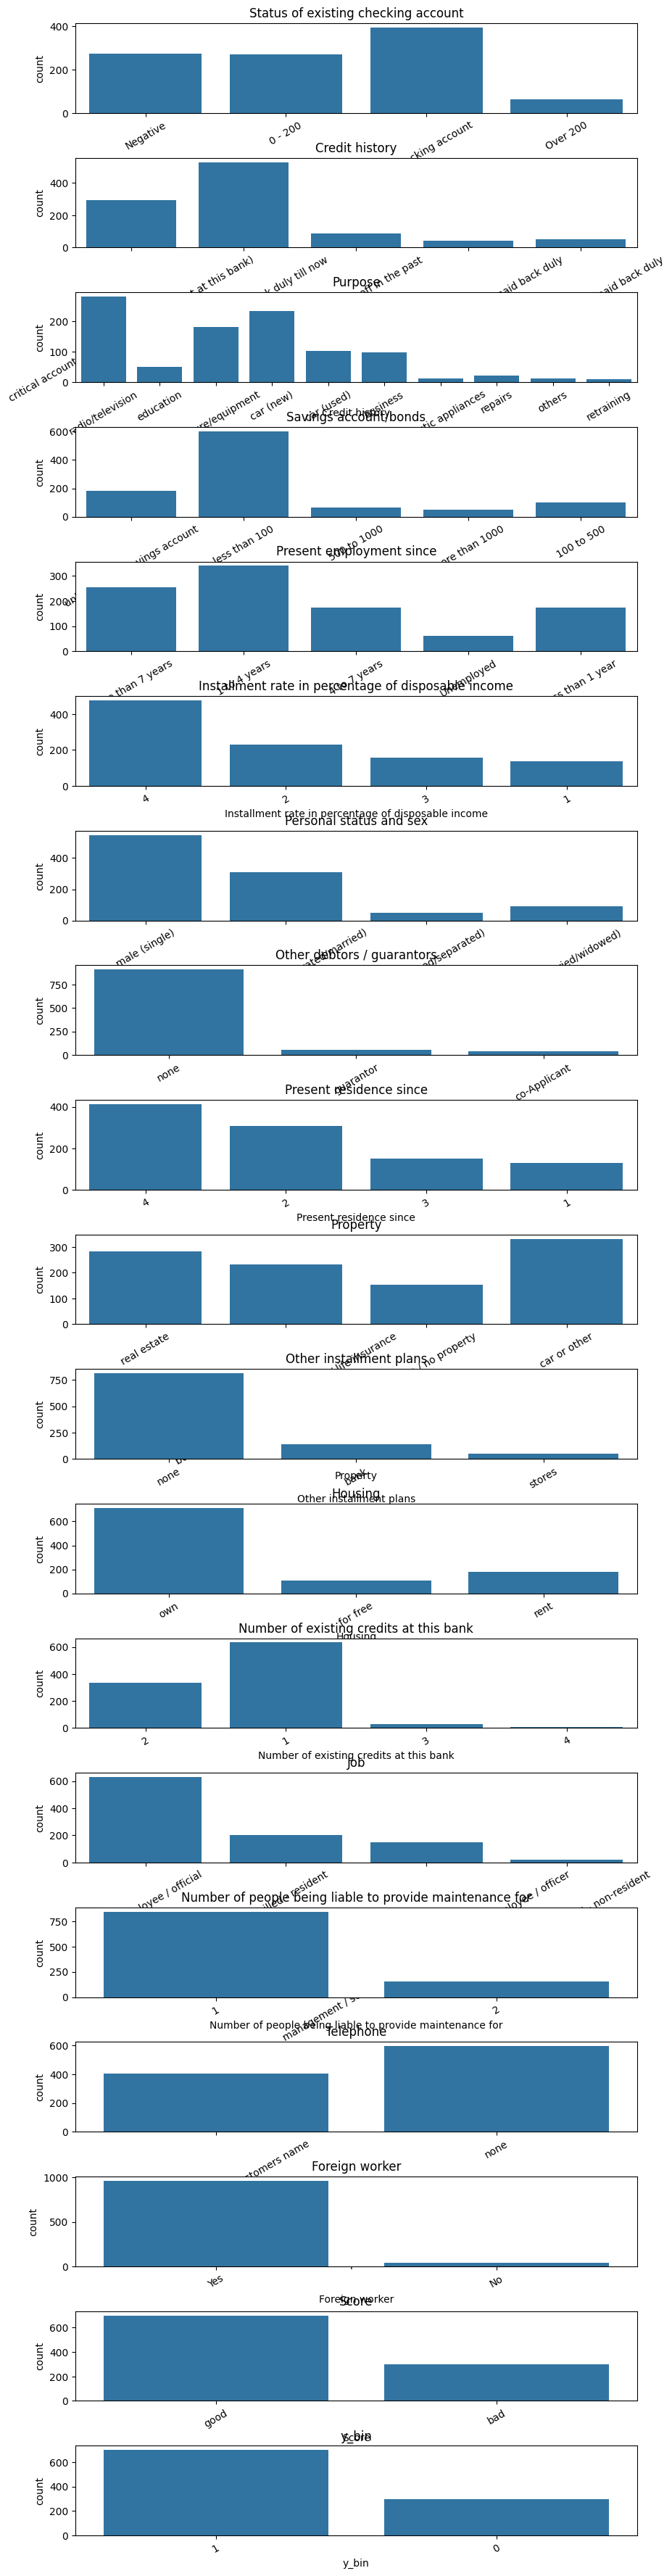

In [ ]:
col_cat = df_calificacion.select_dtypes(object).columns

# Gráficos de barras de conteo
fig, ax = plt.subplots(nrows=len(col_cat), ncols=1, figsize=(10,45))
fig.subplots_adjust(hspace=0.5)

for i, col in enumerate(col_cat):
  sns.countplot(x=col, data=df_calificacion, ax=ax[i])
  ax[i].set_title(col)
  ax[i].set_xticklabels(ax[i].get_xticklabels(),rotation=30)

**#Campos a eliminar**

Foreign work

other debtor

Telephono

Number of people being liable to provide maintenance for

Other installment plans

Housing

credito desbalanceado (cuidado en mi modelo)


<Axes: >

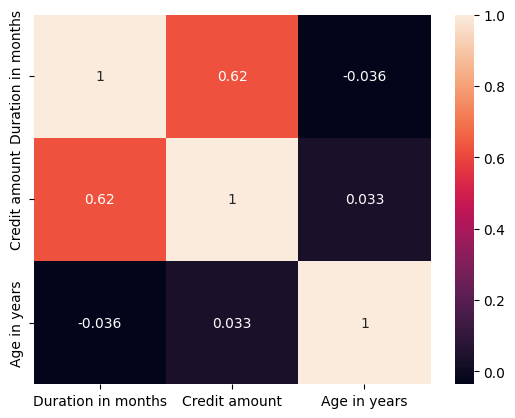

In [ ]:
sns.heatmap(df_calificacion.corr(numeric_only=True), annot=True)

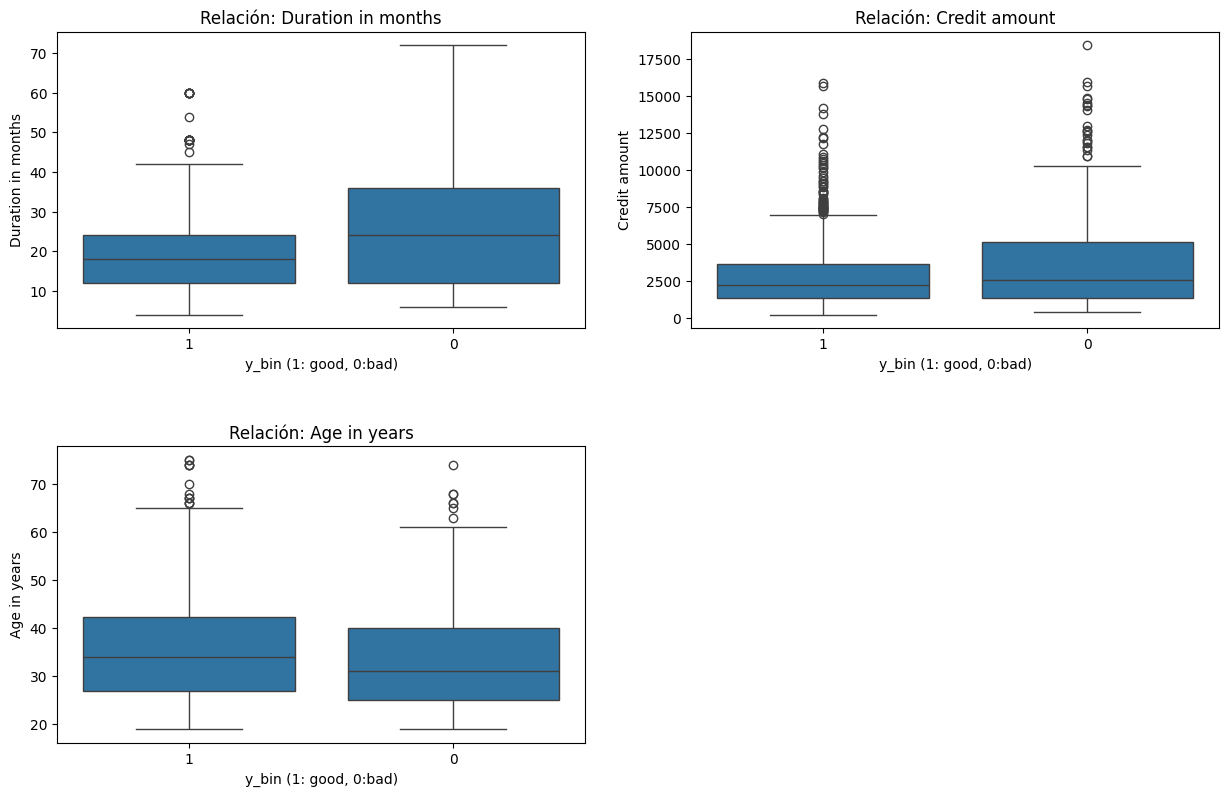

In [ ]:
# 1. Seleccionar columnas numéricas
col_num = ['Duration in months','Credit amount', 'Age in years']

# 2. Ajustar el tamaño (proporción 15 de ancho por 20 de alto para 4 filas)
fig, ax = plt.subplots(nrows=4, ncols=2, figsize=(15, 20))
fig.subplots_adjust(hspace=.4) # Un poco más de espacio para los títulos

# 3. .flatten() convierte la matriz 4x2 en una lista de 8 elementos
ax = ax.flatten()

for i, col in enumerate(col_num):
    # Solo graficamos si no nos pasamos del número de ejes disponibles
    if i < len(ax):
        sns.boxplot(x="y_bin", y=col, data=df_calificacion, ax=ax[i])
        ax[i].set_xlabel('y_bin (1: good, 0:bad)')
        ax[i].set_title(f'Relación: {col}')

# 4. Eliminar ejes vacíos si sobran (por si tienes menos de 8 columnas)
for j in range(i + 1, len(ax)):
    fig.delaxes(ax[j])

plt.show()

In [ ]:
df_calificacion_cl = df_calificacion.drop(columns = ['Foreign worker','Other debtors / guarantors', 'Telephone' ,
                                                     'Number of people being liable to provide maintenance for', 'Other installment plans',
                                                     'Housing','Score'])

#Modelo Regresion Logistica

In [ ]:
#Modelo de regresion Logistica
from sklearn.model_selection import train_test_split
import statsmodels.api as sm
from sklearn.metrics import roc_curve, auc

In [ ]:
print(df_calificacion_cl.dtypes)

Status of existing checking account                    object
Duration in months                                      int64
Credit history                                         object
Purpose                                                object
Credit amount                                           int64
Savings account/bonds                                  object
Present employment since                               object
Installment rate in percentage of disposable income    object
Personal status and sex                                object
Present residence since                                object
Property                                               object
Age in years                                            int64
Number of existing credits at this bank                object
Job                                                    object
y_bin                                                  object
dtype: object


In [ ]:
# 1. Definimos las columnas que son 'object' (categorías)
columnas_categoricas = ['Status of existing checking account','Credit history',
                                              'Purpose','Savings account/bonds','Present employment since','Installment rate in percentage of disposable income',
                                              'Personal status and sex', 'Present residence since','Property',
                                              'Number of existing credits at this bank','Job']

# 2. Transformar a Dummies
# drop_first=True evita la redundancia (la "trampa de la variable dummy")
df_final = pd.get_dummies(df_calificacion_cl, columns=columnas_categoricas, drop_first=True)

# 3. Asegurarnos de que el resto de columnas sean numéricas
# Convertimos a float para que statsmodels no tenga problemas de tipos
df_final = df_final.astype(float)

In [ ]:
#Supuesto de multicolinealdiad
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Suponiendo que 'X' es tu DataFrame de variables independientes
vif_data = pd.DataFrame()
vif_data["Variable"] = df_final.columns
vif_data["VIF"] = [variance_inflation_factor(df_final.values, i) for i in range(len(df_final.columns))]

print(vif_data.sort_values(by="VIF", ascending=False))

#Age in year

                                             Variable        VIF
2                                        Age in years  13.742245
9   Credit history_existing credits paid back duly...  10.316282
0                                  Duration in months   8.082892
7   Credit history_critical account/ other credits...   7.539291
21                Savings account/bonds_less than 100   7.078842
43                    Job_skilled employee / official   6.154851
1                                       Credit amount   5.756145
30  Installment rate in percentage of disposable i...   5.458484
36                          Present residence since_4   4.710140
3                                               y_bin   4.406247
17                           Purpose_radio/television   4.100859
34                          Present residence since_2   3.517021
11                                  Purpose_car (new)   3.513883
33              Personal status and sex_male (single)   3.321550
15                       

In [ ]:
df_final_cl = df_final.drop(columns = ['Age in years'])

In [ ]:
np.random.seed(123)

# 4. Definir X y Y
X = df_final_cl.drop(columns=['y_bin']) # Tu variable objetivo
y = df_final_cl['y_bin']

# 5. Agregar el Intercepto (La constante que R agrega sola)
X = sm.add_constant(X)

# 6. División Train/Test (85% - 15%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.15, random_state=123, stratify=y
)

# 7. Ejecutar Regresión Logística
modelo_final = sm.Logit(y_train, X_train).fit()

# 8. Ver el resumen (Aquí verás los P-valores y el AIC)
print(modelo_final.summary())

         Current function value: 0.440675
         Iterations: 35
                           Logit Regression Results                           
Dep. Variable:                  y_bin   No. Observations:                  850
Model:                          Logit   Df Residuals:                      805
Method:                           MLE   Df Model:                           44
Date:                Sun, 01 Mar 2026   Pseudo R-squ.:                  0.2786
Time:                        22:39:02   Log-Likelihood:                -374.57
converged:                      False   LL-Null:                       -519.23
Covariance Type:            nonrobust   LLR p-value:                 7.963e-38
                                                                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------------------------------------------------
const           

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [ ]:
import statsmodels.api as sm

def backward_elimination(data, target, significance_level=0.05):
    # Empezamos con todas las columnas de X
    features = data.columns.tolist()
    while len(features) > 0:
        # Ajustar el modelo con las variables actuales
        model = sm.Logit(target, data[features]).fit(disp=False)
        # Obtener el p-value más alto
        p_values = model.pvalues
        max_p_value = p_values.max()

        if max_p_value > significance_level:
            # Identificar la variable con el p-value más alto y eliminarla
            excluded_feature = p_values.idxmax()
            features.remove(excluded_feature)
            print(f"Eliminando '{excluded_feature}' (P-value: {max_p_value:.4f})")
        else:
            break
    return model

# Ejecutar la limpieza automática
# Asegúrate de usar X_train y y_train de tu paso anterior
modelo_optimizado = backward_elimination(X_train, y_train)

# Ver el resultado final impecable
print("\n" + "="*50)
print("MODELO FINAL OPTIMIZADO")
print("="*50)
print(modelo_optimizado.summary())
print(f"\nAIC Final: {modelo_optimizado.aic:.2f}")

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Eliminando 'Purpose_retraining' (P-value: 0.9999)
Eliminando 'Purpose_repairs' (P-value: 0.9744)
Eliminando 'Present employment since_Unemployed' (P-value: 0.9453)
Eliminando 'Property_car or other' (P-value: 0.8634)
Eliminando 'Purpose_radio/television' (P-value: 0.7169)
Eliminando 'Present employment since_more than 7 years' (P-value: 0.6460)
Eliminando 'Personal status and sex_male (divorced/separated)' (P-value: 0.6105)
Eliminando 'Credit history_no credits taken / all credits paid back duly' (P-value: 0.6014)
Eliminando 'Purpose_others' (P-value: 0.6204)
Eliminando 'Number of existing credits at this bank_4' (P-value: 0.5634)
Eliminando 'Savings account/bonds_less than 100' (P-value: 0.5884)
Eliminando 'Job_unemployed / unskilled - non-resident' (P-value: 0.5250)
Eliminando 'Property_real estate' (P-value: 0.5372)
Eliminando 'Number of existing credits at this bank_3' (P-value: 0.3931)
Eliminando 'Present employment since_less than 1 year' (P-value: 0.3779)
Eliminando 'Job_skilled

In [ ]:
from sklearn import metrics # Aseguramos la importación

# 1. Obtener las probabilidades
X_train_final = X_train[modelo_optimizado.model.exog_names]
predictTrain = modelo_optimizado.predict(X_train_final)

# 2. Calcular la Curva ROC
fpr, tpr, thresholds = metrics.roc_curve(y_train, predictTrain)

# 3. Calcular el Área Bajo la Curva (AUC)
# Usamos metrics.auc para evitar el error 'numpy.float64' object is not callable
auc_value = metrics.auc(fpr, tpr)

print(f"Área Bajo la Curva (AUC): {auc_value:.4f}")

Área Bajo la Curva (AUC): 0.8258


In [ ]:
# Método: Maximizar la diferencia entre TPR y FPR (Índice de Youden)
optimal_idx = np.argmax(tpr - fpr)
umbral_optimo = thresholds[optimal_idx]

print(f"Umbral Óptimo Sugerido: {umbral_optimo:.4f}")


#ROC
y_pred_prods = logreg_cv.predict_proba(X_train)[:,1]

from sklearn.metrics import roc_curve
fpr,tpr,threshold = roc_curve(y_train,y_pred_prods)
#AUC
from sklearn.metrics import roc_auc_score
print(roc_auc_score(y_test,y_pred_prods))

uc_value = metrics.auc(fpr, tpr)
print(f"Área Bajo la Curva (AUC): {auc_value:.4f}")


Umbral Óptimo Sugerido: 0.7000


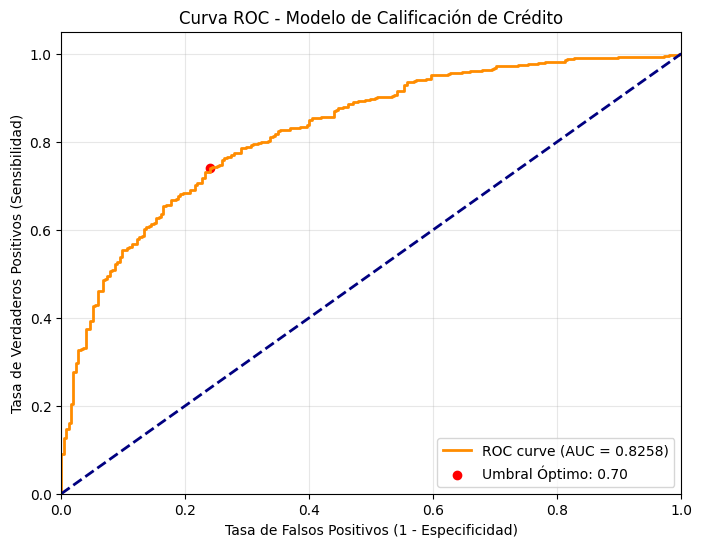

In [ ]:
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {auc_value:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') # Línea de azar

# Marcar el punto óptimo
plt.scatter(fpr[optimal_idx], tpr[optimal_idx], color='red', label=f'Umbral Óptimo: {umbral_optimo:.2f}')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (1 - Especificidad)')
plt.ylabel('Tasa de Verdaderos Positivos (Sensibilidad)')
plt.title('Curva ROC - Modelo de Calificación de Crédito')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

#Asegurar que X_test tenga las mismas columnas que el modelo optimizado
X_test_final = X_test[modelo_optimizado.model.exog_names]

#Obtener probabilidades (Predict en R con type="response")
predictTest = modelo_optimizado.predict(X_test_final)

#Convertir a clase (0 o 1) usando el umbral óptimo
# Esto equivale a tu ifelse(predictTest > umbral_optimo, "Yes", "No")
predicted_class = (predictTest > umbral_optimo).astype(int)

#Definir la clase real
actual_class = y_test

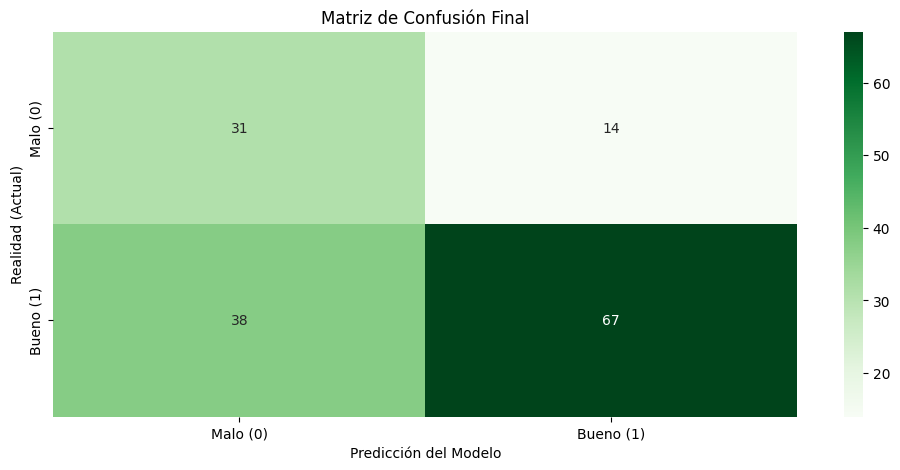

--- Reporte de Clasificación ---
              precision    recall  f1-score   support

    Malo (0)       0.45      0.69      0.54        45
   Bueno (1)       0.83      0.64      0.72       105

    accuracy                           0.65       150
   macro avg       0.64      0.66      0.63       150
weighted avg       0.71      0.65      0.67       150



In [ ]:
cm = confusion_matrix(actual_class, predicted_class)

#Graficar la Matriz de Confusión
plt.figure(figsize=(12, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Malo (0)', 'Bueno (1)'],
            yticklabels=['Malo (0)', 'Bueno (1)'])
plt.xlabel('Predicción del Modelo')
plt.ylabel('Realidad (Actual)')
plt.title('Matriz de Confusión Final')
plt.show()

#Imprimir metricas detalladas
print("--- Reporte de Clasificación ---")
print(classification_report(actual_class, predicted_class, target_names=['Malo (0)', 'Bueno (1)']))

In [ ]:
# Creamos un nuevo DataFrame combinando los valores reales y las predicciones para deteminar otros indicadores....
df_resultados = pd.DataFrame({
    'Realidad': y_test.values,
    'Prediccion': predicted_class
}, index=y_test.index)


print(df_resultados.head())

     Realidad  Prediccion
898       1.0           1
619       1.0           1
994       1.0           1
278       0.0           1
169       0.0           0


#Modelo XGBoost



In [ ]:
import xgboost as xgb
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.15, random_state=123, stratify=y
)


modelo_xgb = xgb.XGBClassifier(
    n_estimators=500,
    learning_rate=0.1,
    max_depth=5,
    early_stopping_rounds=10,
    random_state=123,
    eval_metric='logloss'
)


modelo_xgb.fit(
    X_train,
    y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=10,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=500, n_jobs=None,
              num_parallel_tree=None, ...)

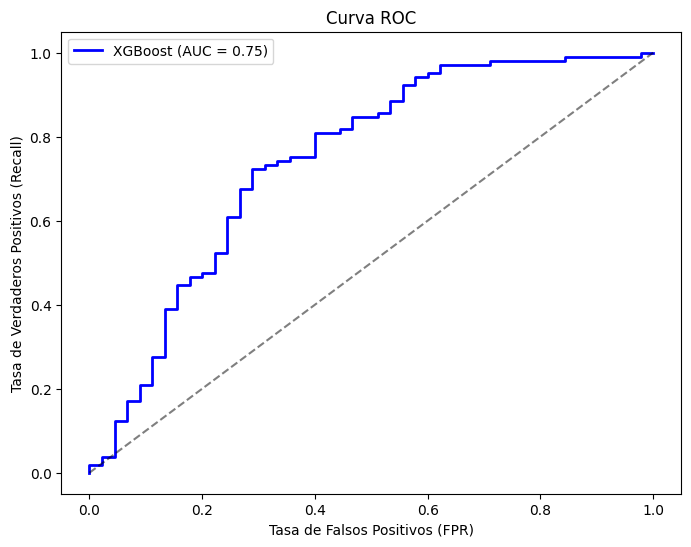

In [ ]:
# Obtenemos las PROBABILIDADES, no las clases (0/1)
y_probs = modelo_xgb.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_probs)
auc = roc_auc_score(y_test, y_probs)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'XGBoost (AUC = {auc:.2f})', color='blue', lw=2)
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (Recall)')
plt.title('Curva ROC')
plt.legend()
plt.show()

In [ ]:
# Buscamos el umbral que maximiza la diferencia entre TPR y FPR (Índice de Youden)
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]

print(f"El umbral óptimo sugerido es: {optimal_threshold:.4f}")

# Aplicamos el nuevo umbral para obtener nuevas predicciones
y_pred_ajustado = (y_probs >= optimal_threshold).astype(int)

El umbral óptimo sugerido es: 0.6558


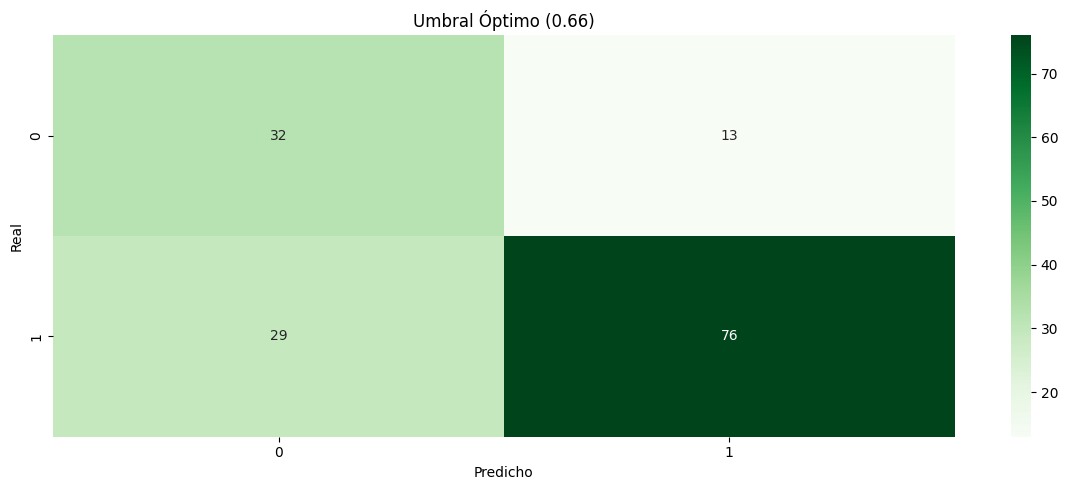

--- Reporte con Umbral Óptimo ---
              precision    recall  f1-score   support

         0.0       0.52      0.71      0.60        45
         1.0       0.85      0.72      0.78       105

    accuracy                           0.72       150
   macro avg       0.69      0.72      0.69       150
weighted avg       0.76      0.72      0.73       150



In [ ]:
# Predicciones con ambos umbrales
y_pred_std = (y_probs >= 0.5).astype(int)
y_pred_opt = (y_probs >= optimal_threshold).astype(int)

fig, ax = plt.subplots(figsize=(12, 5))

# Matriz óptima
sns.heatmap(confusion_matrix(y_test, y_pred_opt), annot=True, fmt='d', ax=ax, cmap='Greens')
ax.set_title(f'Umbral Óptimo ({optimal_threshold:.2f})')
ax.set_xlabel('Predicho')
ax.set_ylabel('Real')

plt.tight_layout()
plt.show()

print("--- Reporte con Umbral Óptimo ---")
print(classification_report(y_test, y_pred_opt))

<Figure size 1000x800 with 0 Axes>

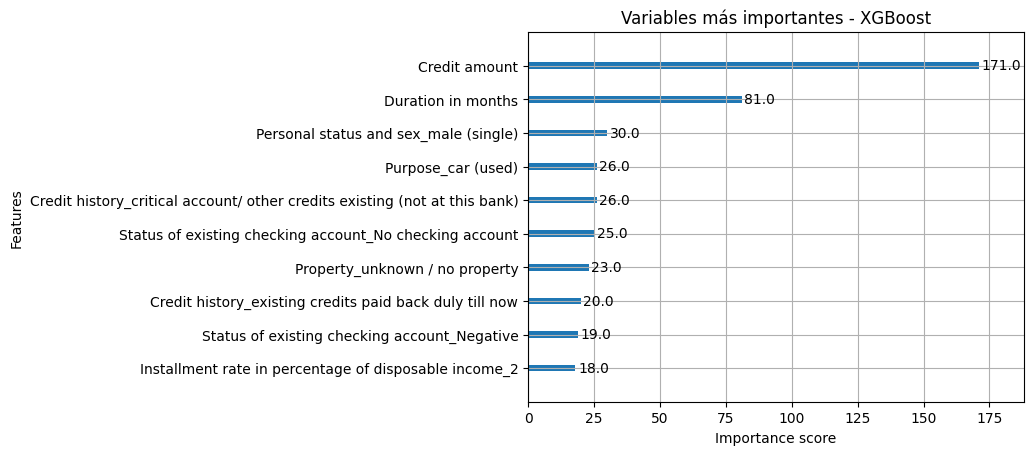

In [ ]:
# Graficar de forma automática
plt.figure(figsize=(10, 8))
xgb.plot_importance(modelo_xgb, max_num_features=10, importance_type='weight')
plt.title("Variables más importantes - XGBoost")
plt.show()


In [ ]:
# Create the parameter space
params = {"penalty": ["l1", "l2"],
         "tol": np.linspace(0.0001, 1.0, 50),
         "C": np.linspace(0.1, 1.0, 50),
         "class_weight": ["balanced", {0:0.8, 1:0.2}]}

# Instantiate the RandomizedSearchCV object
logreg_cv = RandomizedSearchCV(logreg, params, cv=kf)

# Fit the data to the model
logreg_cv.fit(X_train, y_train)

# Print the tuned parameters and score
print("Tuned Logistic Regression Parameters: {}".format(logreg_cv.best_params_))
print("Tuned Logistic Regression Best Accuracy Score: {}".format(logreg_cv.best_score_))

#ROC
y_pred_prods = logreg_cv.predict_proba(X_train)[:,1]

from sklearn.metrics import roc_curve
fpr,tpr,threshold = roc_curve(y_train,y_pred_prods)

optimal_idx = np.argmax(tpr - fpr)
umbral_optimo = threshold[optimal_idx]

print(f"Umbral Óptimo Sugerido: {umbral_optimo:.4f}")

#AUC
from sklearn.metrics import roc_auc_score
print(roc_auc_score(y_train,y_pred_prods))

from sklearn import metrics
auc_value = metrics.auc(fpr, tpr)
print(f"Área Bajo la Curva (AUC): {auc_value:.4f}")

# Evaluacion en el modelo de Test
y_probs_test = logreg_cv.predict_proba(X_test)[:, 1]

fpr,tpr,threshold = roc_curve(y_test,y_probs_test)
auc_value = metrics.auc(fpr, tpr)
print(f"Área Bajo la Curva (AUC): {auc_value:.4f}")

# 4. Aplicar el umbral de TRAIN a los datos de TEST
y_pred_final = (y_probs_test >= umbral_optimo).astype(int)

# 5. Evaluación Final
from sklearn.metrics import confusion_matrix, classification_report
print("--- Evaluación Final en TEST con el umbral de TRAIN ---")
print(confusion_matrix(y_test, y_pred_final))
print(classification_report(y_test, y_pred_final))

